# 01 — Signal Generation Demo

This notebook demonstrates the signal-generation workflow used in the CBC parameter-estimation project.

The goal is not to generate the full research dataset. Large datasets should be generated with the dedicated HDF5 generation script and versioned configuration files.

Here we focus on understanding the individual steps of the workflow:

1. define the simulation configuration;
2. define or sample physical CBC parameters;
3. generate the geocentric plus/cross waveform;
4. project the waveform onto a detector network;
5. select a common time window across detectors;
6. place the signal inside a fixed-duration strain segment;
7. compute signal-only SNR and apply distance rescaling when needed;
8. inject the signal into detector noise;
9. process the strain;
10. build a complete `DatasetSample`;
11. inspect metadata and labels.

## 1. Imports and project setup

We first configure the notebook environment, import the project modules, and define a few plotting helpers.

The notebook is intended to be run from the `notebooks/` directory. If your working directory is different, adjust `PROJECT_ROOT` accordingly.

In [1]:
from pathlib import Path
import sys
import json
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe


In [3]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import PriorConfig, ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.windowing import ProjectedNetworkWindowSelector
from src.injection import SignalInjector
from src.noise import NoiseModel
from src.processing import SignalProcessor
from src.dataset import DatasetBuilder
from src.labels import LabelTransformer

from src.snr import (
    compute_network_optimal_snr,
    decide_distance_rescaling,
    validate_snr_rescaling,
)

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [64]:
def timeseries_to_arrays(ts, relative_to=None):
    """
    Convert a PyCBC TimeSeries into numpy time/value arrays.

    Parameters
    ----------
    ts:
        PyCBC TimeSeries.
    relative_to:
        Optional reference time. If provided, the returned time axis is shifted
        by this value.
    """
    t = np.arange(len(ts)) * float(ts.delta_t) + float(ts.start_time)

    if relative_to is not None:
        t = t - float(relative_to)

    y = np.asarray(ts)
    return t, y


def plot_timeseries_dict(
    strains,
    title="",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    alpha=0.8,
):
    """
    Plot a dictionary of detector TimeSeries objects in the same axes.
    """
    plt.figure(figsize=(14, 4))

    for name, ts in strains.items():
        t, y = timeseries_to_arrays(ts, relative_to=relative_to)
        plt.plot(t, y, label=name, alpha=alpha)

    plt.xlabel("Time [s]" if relative_to is None else "Time relative to reference [s]")
    plt.ylabel(ylabel)
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_timeseries_dict_subplots(
    strains,
    title="",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    sharex=True,
):
    """
    Plot a dictionary of detector TimeSeries objects using one subplot per detector.

    This is usually better for noisy data, where overlaying all detectors in one
    axis makes the plot hard to read.
    """
    detector_names = list(strains.keys())
    n_detectors = len(detector_names)

    fig, axes = plt.subplots(
        n_detectors,
        1,
        figsize=(14, 2.6 * n_detectors),
        sharex=sharex,
    )

    if n_detectors == 1:
        axes = [axes]

    for ax, det in zip(axes, detector_names):
        t, y = timeseries_to_arrays(strains[det], relative_to=relative_to)

        ax.plot(t, y, label=det, alpha=0.9)
        ax.set_ylabel(ylabel)
        ax.set_title(det)
        ax.grid(alpha=0.3)

        if xlim is not None:
            ax.set_xlim(*xlim)

    axes[-1].set_xlabel(
        "Time [s]" if relative_to is None else "Time relative to reference [s]"
    )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_signal_noise_overlay_subplots(
    injected_strains,
    signal_only_segments,
    title="Signal + noise compared with signal-only waveform",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    signal_scale=1.0,
):
    """
    Plot signal+noise and signal-only data for each detector.

    signal_scale can be used to visually amplify the signal-only curve.
    Use signal_scale=1.0 to keep the physical amplitude.
    """
    detector_names = list(injected_strains.keys())
    n_detectors = len(detector_names)

    fig, axes = plt.subplots(
        n_detectors,
        1,
        figsize=(14, 2.8 * n_detectors),
        sharex=True,
    )

    if n_detectors == 1:
        axes = [axes]

    for ax, det in zip(axes, detector_names):
        t_inj, y_inj = timeseries_to_arrays(
            injected_strains[det],
            relative_to=relative_to,
        )
        t_sig, y_sig = timeseries_to_arrays(
            signal_only_segments[det],
            relative_to=relative_to,
        )

        ax.plot(t_inj, y_inj, label="signal + noise", alpha=0.75)
        ax.plot(
            t_sig,
            signal_scale * y_sig,
            label=(
                "signal-only"
                if signal_scale == 1.0
                else f"signal-only × {signal_scale:g}"
            ),
            alpha=0.9,
        )

        ax.set_ylabel(ylabel)
        ax.set_title(det)
        ax.grid(alpha=0.3)

        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.legend(loc="upper right")

    axes[-1].set_xlabel(
        "Time [s]" if relative_to is None else "Time relative to reference [s]"
    )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_array_network(X, detector_names, sampling_frequency, title="", xlim=None):
    """
    Plot a network array with shape (n_detectors, n_samples) in one shared axis.
    """
    t = np.arange(X.shape[-1]) / sampling_frequency

    plt.figure(figsize=(14, 4))

    for det_idx, det in enumerate(detector_names):
        plt.plot(t, X[det_idx], label=det, alpha=0.8)

    plt.xlabel("Time [s]")
    plt.ylabel("Processed strain")
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_array_network_subplots(
    X,
    detector_names,
    sampling_frequency,
    title="",
    ylabel="Processed strain",
    xlim=None,
):
    """
    Plot a network array with shape (n_detectors, n_samples), one subplot per detector.
    """
    t = np.arange(X.shape[-1]) / sampling_frequency

    fig, axes = plt.subplots(
        len(detector_names),
        1,
        figsize=(14, 2.6 * len(detector_names)),
        sharex=True,
    )

    if len(detector_names) == 1:
        axes = [axes]

    for det_idx, det in enumerate(detector_names):
        axes[det_idx].plot(t, X[det_idx], label=det, alpha=0.9)
        axes[det_idx].set_ylabel(ylabel)
        axes[det_idx].set_title(det)
        axes[det_idx].grid(alpha=0.3)

        if xlim is not None:
            axes[det_idx].set_xlim(*xlim)

    axes[-1].set_xlabel("Time [s]")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def print_dict_tree(d, indent=0, max_depth=3):
    """
    Print a compact tree view of a nested dictionary.
    """
    if indent // 2 >= max_depth:
        return

    if isinstance(d, dict):
        for key, value in d.items():
            print(" " * indent + str(key))
            print_dict_tree(value, indent + 2, max_depth=max_depth)
    elif isinstance(d, list):
        print(" " * indent + f"[list, len={len(d)}]")
    else:
        print(" " * indent + f"{type(d).__name__}: {d}")

## 2. Simulation configuration

`SimulationConfig` collects the main numerical and physical assumptions used by the generation pipeline.

For this demo we use a 32 s segment sampled at 4096 Hz. This gives:

$$
32 \, \mathrm{s} \times 4096 \, \mathrm{Hz} = 131072 \text{ time samples per detector.}
$$ 

The waveform is generated from 30 Hz using `SEOBNRv4_opt`, and the target network SNR range is set to `[10, 25]`.

In [5]:
config = SimulationConfig(
    simulation_regime="BBH",
    waveform_family="IMR",

    sampling_frequency=4096.0,
    duration=32.0,

    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    target_network_snr_range=(10.0, 25.0),
    snr_relative_tolerance=0.05,
    snr_on_truncated_signal=True,

    truncation_policy="keep_last_segment",
    required_final_duration=1.0,

    safe_margin_start=0.0,
    safe_margin_end=0.0,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

config

SimulationConfig(simulation_regime='BBH', waveform_family='IMR', sampling_frequency=4096.0, duration=32.0, low_frequency_cutoff=30.0, waveform_approximant='SEOBNRv4_opt', target_network_snr_range=(10.0, 25.0), snr_relative_tolerance=0.05, snr_on_truncated_signal=True, truncation_policy='keep_last_segment', required_final_duration=1.0, event_time_reference='geocentric', safe_margin_start=0.0, safe_margin_end=0.0, processing_context_start_samples=1664, processing_context_end_samples=1664)

In [6]:
print("duration:", config.duration, "s")
print("sampling_frequency:", config.sampling_frequency, "Hz")
print("length:", config.length, "samples")
print("delta_t:", config.delta_t, "s")
print("delta_f:", config.delta_f, "Hz")
print("flength:", config.flength)

print()
print("processing_length:", config.processing_length, "samples")
print("processing_duration:", config.processing_duration, "s")
print("processing_delta_f:", config.processing_delta_f, "Hz")
print("processing_flength:", config.processing_flength)

duration: 32.0 s
sampling_frequency: 4096.0 Hz
length: 131072 samples
delta_t: 0.000244140625 s
delta_f: 0.03125 Hz
flength: 65537

processing_length: 134400 samples
processing_duration: 32.8125 s
processing_delta_f: 0.030476190476190476 Hz
processing_flength: 67201


## 3. Physical parameters

A CBC signal is controlled by intrinsic parameters, such as component masses and spins, and extrinsic parameters, such as distance, sky location, inclination, and polarization angle.

For this demo we start with a controlled BBH system:

- $m_1 = 20 M_\odot$
- $m_2 = 20 M_\odot$
- zero aligned spins
- an arbitrary initial distance

The distance may later be rescaled to place the network SNR inside the target range.

In [7]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=20.0,
    distance=1000.0,
    inclination=0.7,
    ra=1.0,
    dec=0.5,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.0,
)

params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=1000.0, inclination=0.7, ra=1.0, dec=0.5, spin_1z=0.0, spin_2z=0.0, polarization_angle=0.0)

In [8]:
print("mass_1:", params.mass_1)
print("mass_2:", params.mass_2)
print("total_mass:", params.total_mass)
print("chirp_mass:", params.chirp_mass)
print("chi_eff:", params.chi_eff)

mass_1: 20.0
mass_2: 20.0
total_mass: 40.0
chirp_mass: 17.411011265922482
chi_eff: 0.0


## 4. Sampling with fixed parameters

The sampler can also be configured to keep some parameters fixed while sampling the rest.

This is useful for controlled demos and targeted generation studies. For example, we can force the component masses and spins while still sampling distance, sky location, inclination, and polarization.

In [9]:
prior = PriorConfig.bbh(
    fixed_parameters={
        "mass_1": 20.0,
        "mass_2": 20.0,
        "spin_1z": 0.0,
        "spin_2z": 0.0,
    }
)

sampler = ParameterSampler(
    prior_config=prior,
    rng=np.random.default_rng(1234),
)

sampled_params = sampler.sample_one()
sampled_params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=4631.581922066986, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156)

In [10]:
print("Sampled parameters:")
print("mass_1:", sampled_params.mass_1)
print("mass_2:", sampled_params.mass_2)
print("distance:", sampled_params.distance)
print("inclination:", sampled_params.inclination)
print("ra:", sampled_params.ra)
print("dec:", sampled_params.dec)
print("spin_1z:", sampled_params.spin_1z)
print("spin_2z:", sampled_params.spin_2z)
print("polarization_angle:", sampled_params.polarization_angle)

assert np.isclose(sampled_params.mass_1, 20.0)
assert np.isclose(sampled_params.mass_2, 20.0)
assert np.isclose(sampled_params.spin_1z, 0.0)
assert np.isclose(sampled_params.spin_2z, 0.0)

Sampled parameters:
mass_1: 20.0
mass_2: 20.0
distance: 4631.581922066986
inclination: 2.06759669959222
ra: 2.004945948992312
dec: -0.8692072862628579
spin_1z: 0.0
spin_2z: 0.0
polarization_angle: 6.05748854826156


## 5. Generate the geocentric waveform

The first physical signal-generation step is to generate the plus and cross gravitational-wave polarizations:

$$
h_+(t), \quad h_\times(t)
$$

At this stage the waveform is still geocentric. It has not yet been projected onto any detector.

In [11]:
waveform_generator = WaveformGenerator(config=config)

waveform = waveform_generator.generate(params)

waveform.metadata

WaveformMetadata(approximant='SEOBNRv4_opt', low_frequency_cutoff=30.0, delta_t=0.000244140625, n_samples=2630, duration=0.64208984375, start_time=-0.565628236, end_time=0.07646160775)

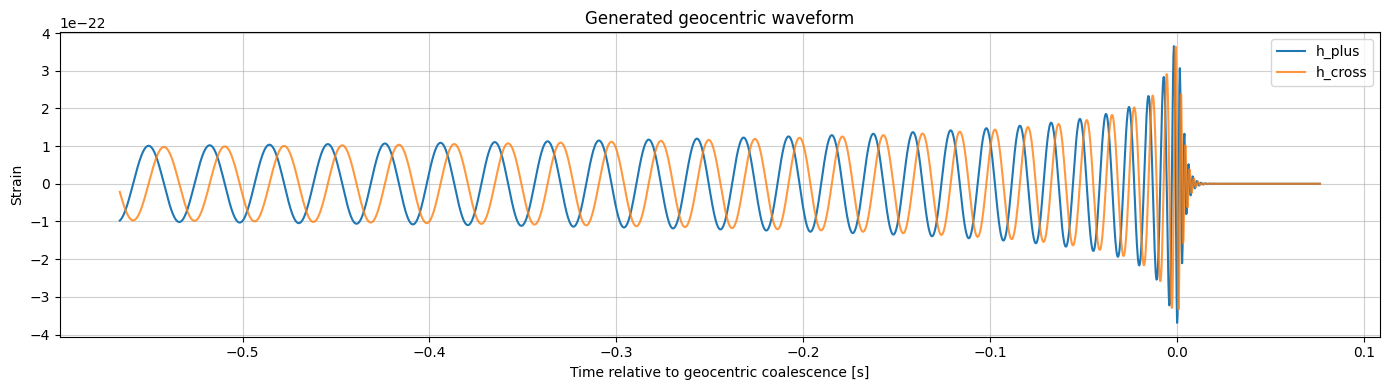

In [15]:
hp = waveform.h_plus
hc = waveform.h_cross

t_hp, y_hp = timeseries_to_arrays(hp)
t_hc, y_hc = timeseries_to_arrays(hc)

plt.figure(figsize=(14, 4))
plt.plot(t_hp, y_hp, label="h_plus")
plt.plot(t_hc, y_hc, label="h_cross", alpha=0.8)
plt.xlabel("Time relative to geocentric coalescence [s]")
plt.ylabel("Strain")
plt.title("Generated geocentric waveform")
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

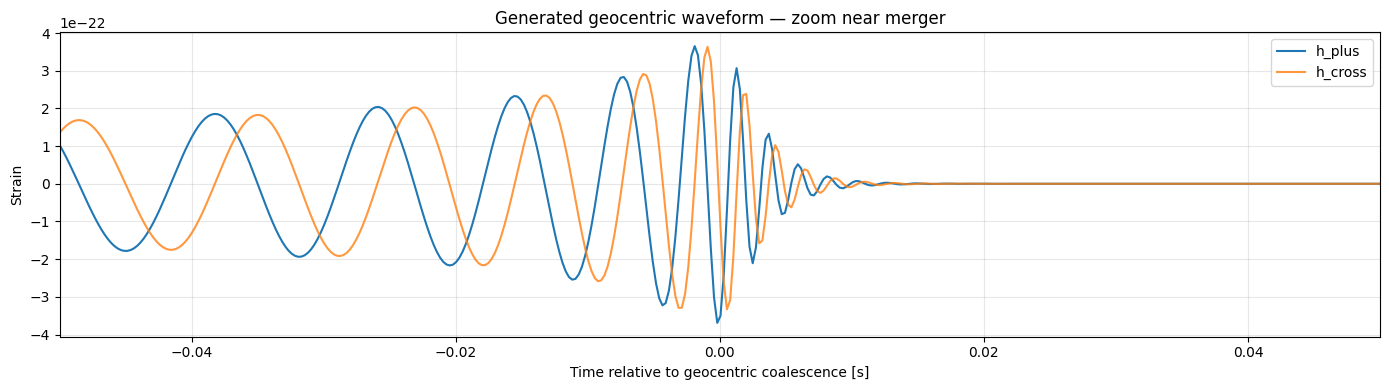

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(t_hp, y_hp, label="h_plus")
plt.plot(t_hc, y_hc, label="h_cross", alpha=0.8)
plt.xlim(-0.05, 0.05)
plt.xlabel("Time relative to geocentric coalescence [s]")
plt.ylabel("Strain")
plt.title("Generated geocentric waveform — zoom near merger")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Project the waveform onto the detector network

The geocentric plus/cross polarizations are projected onto the detector network.

This step applies:

- detector antenna responses;
- sky-location dependence;
- polarization-angle dependence;
- physical detector time delays relative to the geocenter.

The result is a dictionary of detector-frame strains, one per detector.

In [17]:
detector_names = ["H1", "L1", "V1"]
geocentric_coalescence_time = 1126259462.0

projector = DetectorProjector(detector_names=detector_names)

projection = projector.project(
    h_plus=waveform.h_plus,
    h_cross=waveform.h_cross,
    parameters=params,
    geocentric_coalescence_time=geocentric_coalescence_time,
)

projection.metadata

ProjectionMetadata(detector_names=['H1', 'L1', 'V1'], geocentric_coalescence_time=1126259462.0, expected_detector_time_delays={'H1': -0.01778748024381729, 'L1': -0.02111574808831772, 'V1': -0.006068112954319657}, detector_arrival_times={'H1': 1126259461.9822125, 'L1': 1126259461.9788842, 'V1': 1126259461.9939318}, projected_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, projected_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 1126259462.0783691})

In [18]:
print("Expected detector time delays relative to geocenter [s]:")
pprint(projection.metadata.expected_detector_time_delays)

print()
print("Detector arrival times [GPS-like seconds]:")
pprint(projection.metadata.detector_arrival_times)

Expected detector time delays relative to geocenter [s]:
{'H1': -0.01778748024381729,
 'L1': -0.02111574808831772,
 'V1': -0.006068112954319657}

Detector arrival times [GPS-like seconds]:
{'H1': 1126259461.9822125, 'L1': 1126259461.9788842, 'V1': 1126259461.9939318}


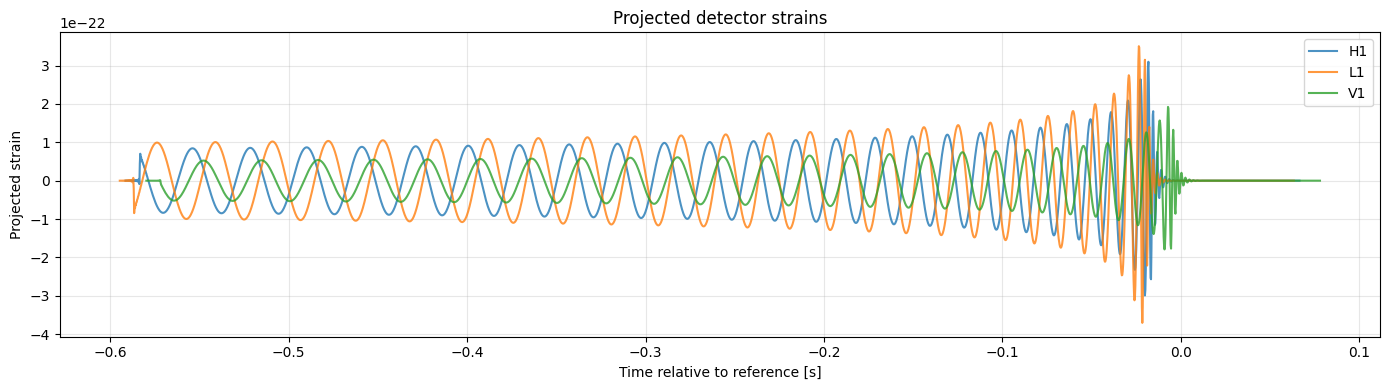

In [19]:
plot_timeseries_dict(
    projection.strains,
    title="Projected detector strains",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
)

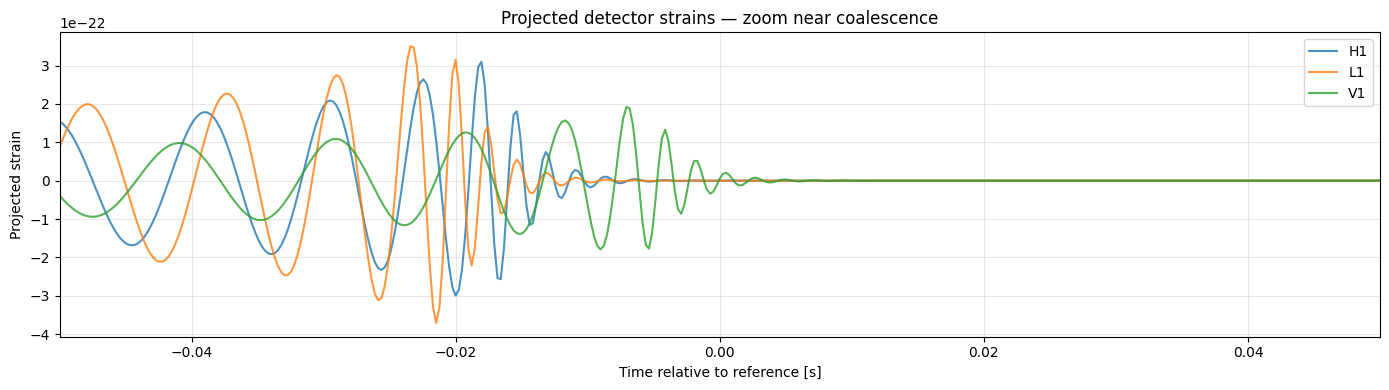

In [23]:
plot_timeseries_dict(
    projection.strains,
    title="Projected detector strains — zoom near coalescence",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
    xlim=(-0.05, 0.05),
)

## 7. Select a common network time window

After projection, the detector strains may not have exactly the same start and end times because the detectors receive the signal with different physical delays.

For this reason, the common network window is selected after projection.

The selected window must be compatible with the fixed segment duration. If the projected network signal is longer than the target duration, the configured truncation policy decides which part is kept.

In [24]:
window_selector = ProjectedNetworkWindowSelector(config=config)

windowed = window_selector.select(
    projected_strains=projection.strains,
    max_duration=config.duration,
)

windowed.metadata

NetworkWindowMetadata(is_truncated=False, truncation_policy='keep_last_segment', detector_names=['H1', 'L1', 'V1'], full_network_start_time=1126259461.4052734, full_network_end_time=1126259462.0783691, full_network_duration=0.673095703125, used_window_start_time=1126259461.4052734, used_window_end_time=1126259462.0783691, used_window_duration=0.673095703125, segment_duration=32.0, max_window_duration=32.0, required_final_duration=1.0, required_available_final_duration=0.673095703125, seconds_before_network_end_in_window=0.673095703125, fraction_network_duration_used=1.0, full_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, full_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 1126259462.0783691}, full_n_samples={'H1': 2697, 'L1': 2697, 'V1': 2696}, used_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, used_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 11262594

In [25]:
print("is_truncated:", windowed.metadata.is_truncated)
print("truncation_policy:", windowed.metadata.truncation_policy)
print("full_network_duration:", windowed.metadata.full_network_duration)
print("used_window_duration:", windowed.metadata.used_window_duration)
print("fraction_network_duration_used:", windowed.metadata.fraction_network_duration_used)
print("seconds_before_network_end_in_window:", windowed.metadata.seconds_before_network_end_in_window)

is_truncated: False
truncation_policy: keep_last_segment
full_network_duration: 0.673095703125
used_window_duration: 0.673095703125
fraction_network_duration_used: 1.0
seconds_before_network_end_in_window: 0.673095703125


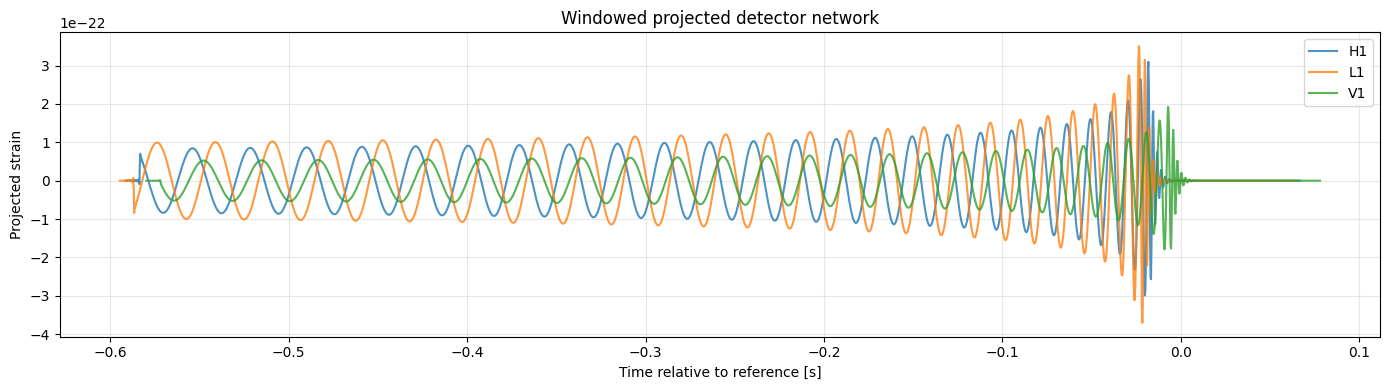

In [26]:
plot_timeseries_dict(
    windowed.strains,
    title="Windowed projected detector network",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
)

## 8. Place the signal inside a fixed-duration segment

The selected detector-network signal is now placed inside a fixed-duration segment.

This step does not add detector noise yet. It only embeds the signal into zero-valued strain segments with the configured duration.

The resulting signal-only segments are useful for computing the optimal SNR before noise injection.

In [27]:
rng = np.random.default_rng(1234)

injector = SignalInjector(
    config=config,
    rng=rng,
)

placement = injector.choose_segment_placement_containing_network(
    signals=windowed.strains,
    placement_policy="random_contained",
    safe_margin_start=config.safe_margin_start,
    safe_margin_end=config.safe_margin_end,
    enforce_safe_margins=True,
)

placement

SegmentPlacement(segment_start_time=1126259460.6753492, segment_end_time=1126259492.6753492, earliest_signal_start_time=1126259461.4052734, latest_signal_end_time=1126259462.0783691, valid_start_min=1126259430.0783691, valid_start_max=1126259461.4052734, placement_policy='random_contained', signal_network_duration=0.673095703125, safe_margin_start=0.0, safe_margin_end=0.0, margin_before_signal=0.729924201965332, margin_after_signal=30.596980094909668, margins_respected=True, enforce_safe_margins=True)

In [29]:
print("segment_start_time:", placement.segment_start_time)
print("segment_end_time:", placement.segment_end_time)
print("earliest_signal_start_time:", placement.earliest_signal_start_time)
print("latest_signal_end_time:", placement.latest_signal_end_time)
print("signal_network_duration:", placement.signal_network_duration)
print("margin_before_signal:", placement.margin_before_signal)
print("margin_after_signal:", placement.margin_after_signal)

segment_start_time: 1126259460.6753492
segment_end_time: 1126259492.6753492
earliest_signal_start_time: 1126259461.4052734
latest_signal_end_time: 1126259462.0783691
signal_network_duration: 0.673095703125
margin_before_signal: 0.729924201965332
margin_after_signal: 30.596980094909668


In [30]:
zero_segments = {
    det: injector.build_zero_strain(
        start_time=placement.segment_start_time,
        length=config.length,
    )
    for det in detector_names
}

signal_only_results = injector.inject_network(
    noises=zero_segments,
    signals=windowed.strains,
)

signal_only_segments = {
    det: result.strain
    for det, result in signal_only_results.items()
}

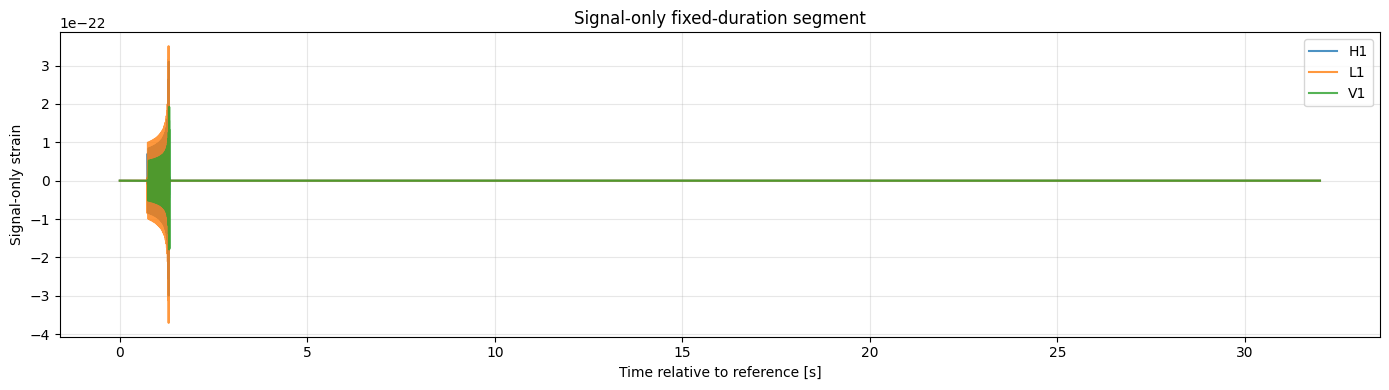

In [31]:
plot_timeseries_dict(
    signal_only_segments,
    title="Signal-only fixed-duration segment",
    ylabel="Signal-only strain",
    relative_to=placement.segment_start_time,
)

## 9. Compute signal-only network SNR

The signal-only fixed-duration segments are used to compute the optimal matched-filter SNR.

The SNR is computed independently for each detector and then combined into a network SNR:

$$
\rho_\mathrm{network} = \sqrt{\sum_i \rho_i^2}
$$

If the network SNR is outside the configured target range, the luminosity distance can be rescaled and the signal regenerated.

In [33]:
noise_model = NoiseModel(config=config)

psds = {
    det: noise_model.get_psd(det)
    for det in detector_names
}

detector_snrs, network_snr = compute_network_optimal_snr(
    signal_segments=signal_only_segments,
    psds=psds,
    config=config,
)

print("Detector SNRs:")
pprint(detector_snrs)

print()
print("Network SNR:", network_snr)

Detector SNRs:
{'H1': 17.13159104264575, 'L1': 20.284256963140223, 'V1': 8.691851824162969}

Network SNR: 27.937265083260527


In [34]:
snr_decision = decide_distance_rescaling(
    current_distance=params.distance,
    current_network_snr=network_snr,
    target_network_snr_range=config.target_network_snr_range,
    rng=rng,
)

snr_decision

SNRRescalingDecision(should_rescale=True, current_network_snr=27.937265083260527, target_network_snr=15.702936025294267, old_distance=1000.0, new_distance=1779.1109279347008, reason='outside_target_range')

In [35]:
print("should_rescale:", snr_decision.should_rescale)
print("reason:", snr_decision.reason)
print("current_network_snr:", snr_decision.current_network_snr)
print("target_network_snr:", snr_decision.target_network_snr)
print("old_distance:", snr_decision.old_distance)
print("new_distance:", snr_decision.new_distance)

should_rescale: True
reason: outside_target_range
current_network_snr: 27.937265083260527
target_network_snr: 15.702936025294267
old_distance: 1000.0
new_distance: 1779.1109279347008


## 10. Rebuild the signal after distance rescaling

If distance rescaling is required, we build a new parameter object with the rescaled distance and regenerate the projected signal network.

This is necessary because the waveform amplitude depends on the luminosity distance.

In [36]:
if snr_decision.should_rescale:
    final_params = params.with_distance(snr_decision.new_distance)
else:
    final_params = params

final_params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=1779.1109279347008, inclination=0.7, ra=1.0, dec=0.5, spin_1z=0.0, spin_2z=0.0, polarization_angle=0.0)

In [38]:
final_waveform = waveform_generator.generate(final_params)

final_projection = projector.project(
    h_plus=final_waveform.h_plus,
    h_cross=final_waveform.h_cross,
    parameters=final_params,
    geocentric_coalescence_time=geocentric_coalescence_time,
)

final_windowed = window_selector.select(
    projected_strains=final_projection.strains,
    max_duration=config.duration,
)

final_placement = injector.choose_segment_placement_containing_network(
    signals=final_windowed.strains,
    placement_policy="random_contained",
    safe_margin_start=config.safe_margin_start,
    safe_margin_end=config.safe_margin_end,
    enforce_safe_margins=True,
)

final_zero_segments = {
    det: injector.build_zero_strain(
        start_time=final_placement.segment_start_time,
        length=config.length,
    )
    for det in detector_names
}

final_signal_only_results = injector.inject_network(
    noises=final_zero_segments,
    signals=final_windowed.strains,
)

final_signal_only_segments = {
    det: result.strain
    for det, result in final_signal_only_results.items()
}

final_detector_snrs, final_network_snr = compute_network_optimal_snr(
    signal_segments=final_signal_only_segments,
    psds=psds,
    config=config,
)

print("Final detector SNRs:")
pprint(final_detector_snrs)

print()
print("Final network SNR:", final_network_snr)

Final detector SNRs:
{'H1': 9.629298979425153, 'L1': 11.401344707992665, 'V1': 4.885503027207527}

Final network SNR: 15.70293602529427


In [39]:
if snr_decision.should_rescale:
    validate_snr_rescaling(
        final_network_snr=final_network_snr,
        target_network_snr=snr_decision.target_network_snr,
        relative_tolerance=config.snr_relative_tolerance,
    )

print("SNR validation passed.")

SNR validation passed.


## 11. Generate detector noise and inject the signal

We now generate Gaussian detector noise from the configured detector PSDs and inject the projected signal into the noise.

This produces the raw noisy strain before whitening, filtering, or cropping.

In [40]:
noises = noise_model.sample_network(
    detector_names=detector_names,
    seed=1234,
    length=config.length,
)

noises = {
    det: injector.set_strain_start_time(
        strain=noise,
        start_time=final_placement.segment_start_time,
        expected_length=config.length,
    )
    for det, noise in noises.items()
}

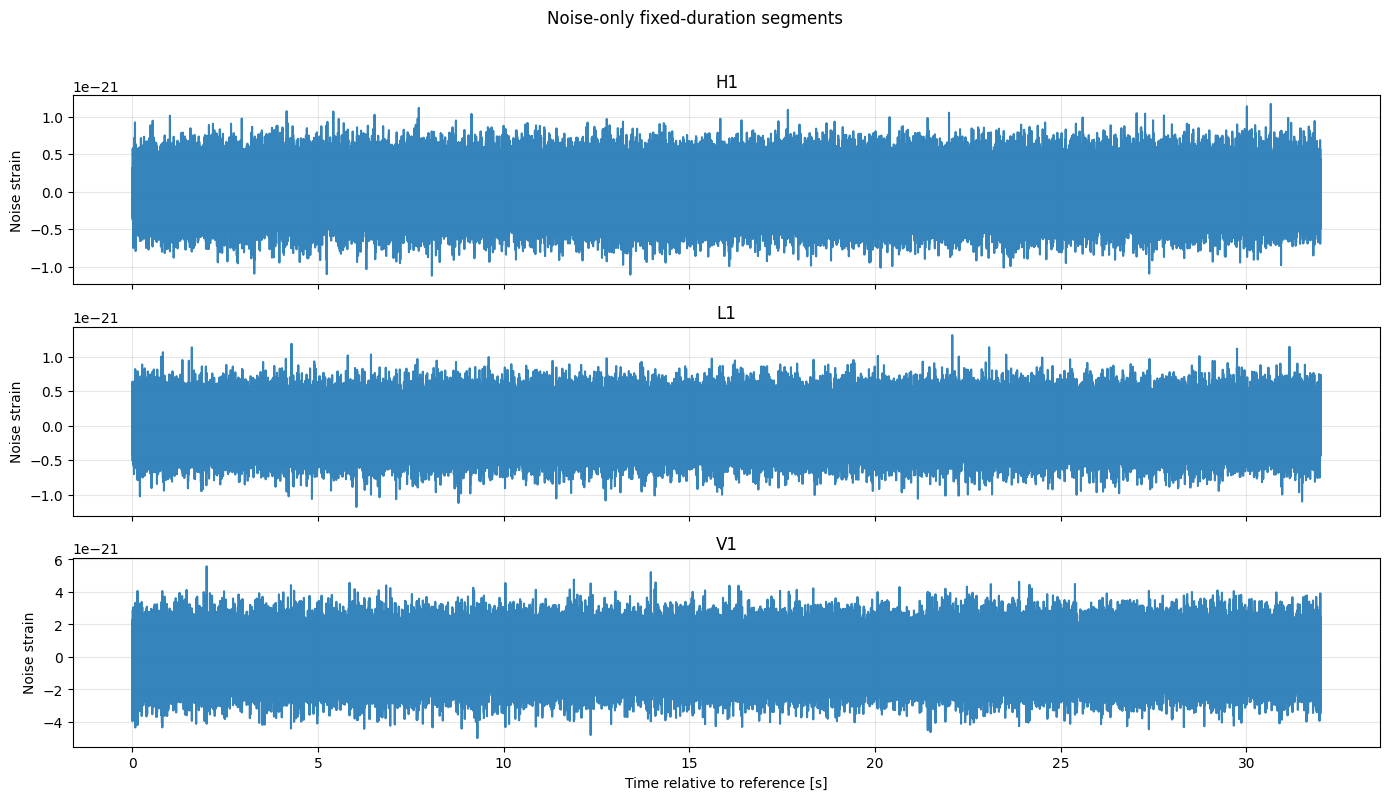

In [65]:
plot_timeseries_dict_subplots(
    noises,
    title="Noise-only fixed-duration segments",
    ylabel="Noise strain",
    relative_to=final_placement.segment_start_time,
)

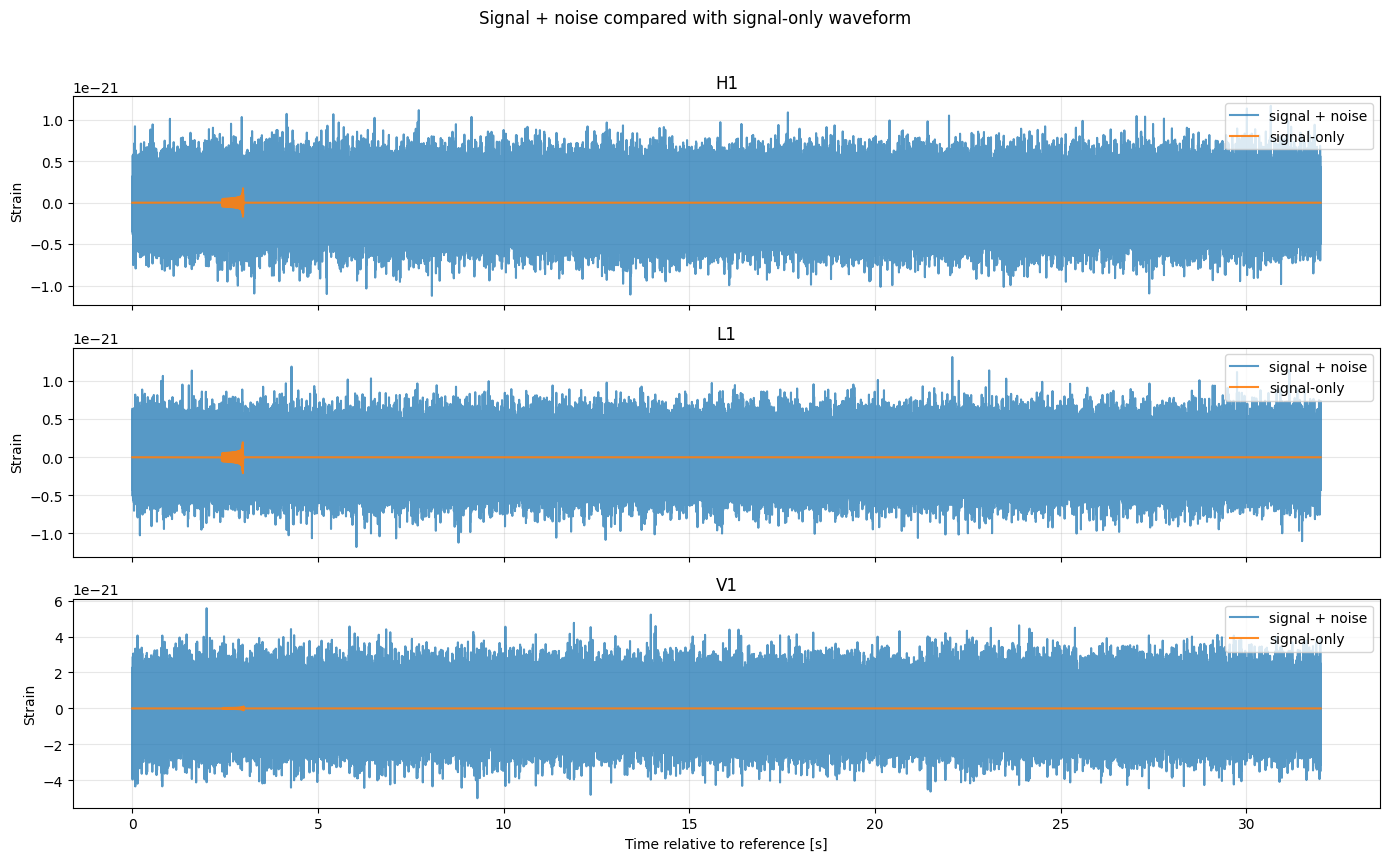

In [67]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise compared with signal-only waveform",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    signal_scale=1.0,
)

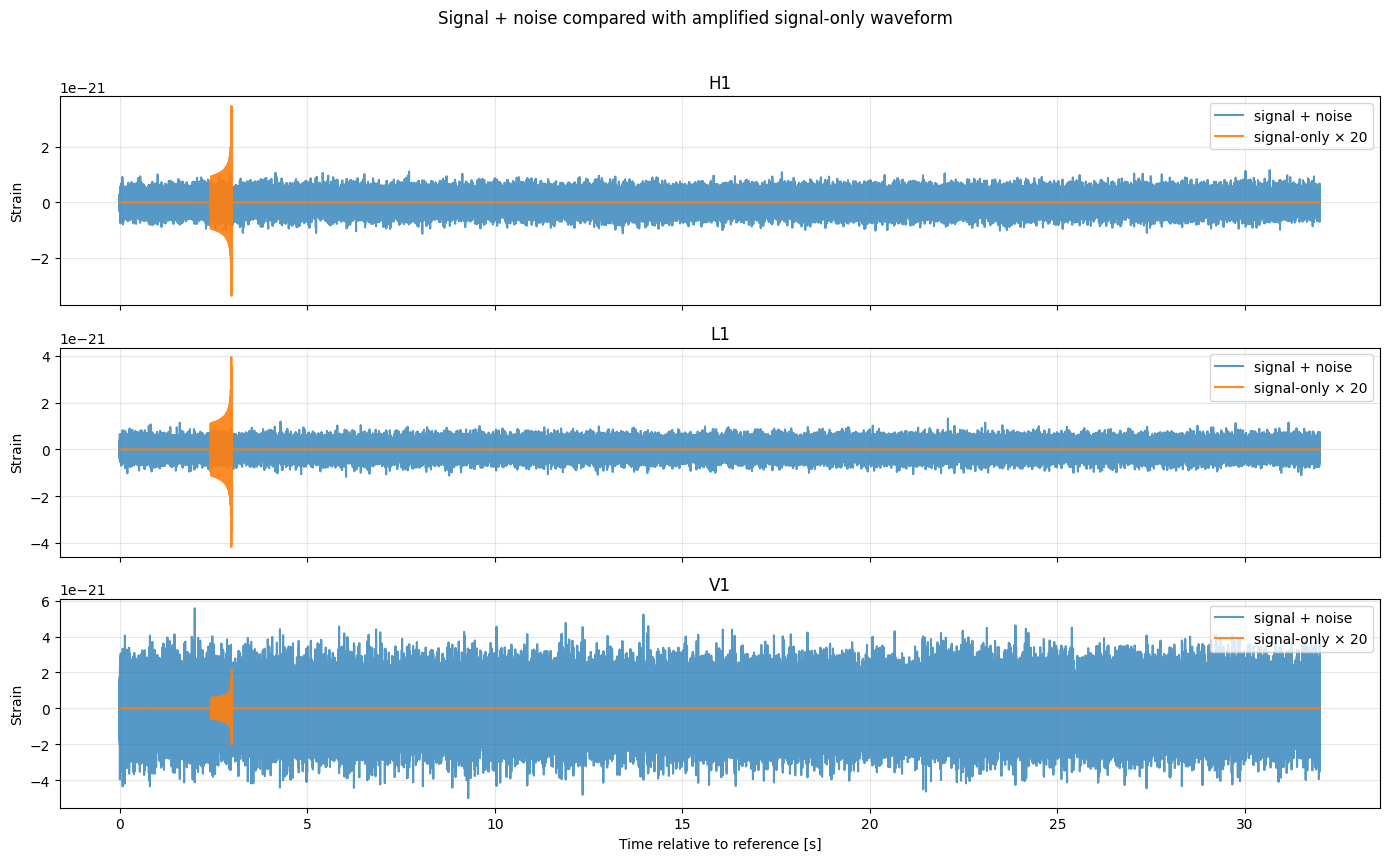

In [68]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise compared with amplified signal-only waveform",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    signal_scale=20.0,
)

In [69]:
# Use the network injection metadata to define a zoom window around the signal.
relative_starts = []
relative_ends = []

for det, result in injected_results.items():
    relative_starts.append(result.signal_start_time - result.segment_start_time)
    relative_ends.append(result.signal_end_time - result.segment_start_time)

zoom_start = max(0.0, min(relative_starts) - 0.5)
zoom_end = min(config.duration, max(relative_ends) + 0.5)

print("zoom_start:", zoom_start)
print("zoom_end:", zoom_end)

zoom_start: 1.9044578075408936
zoom_end: 3.5775535106658936


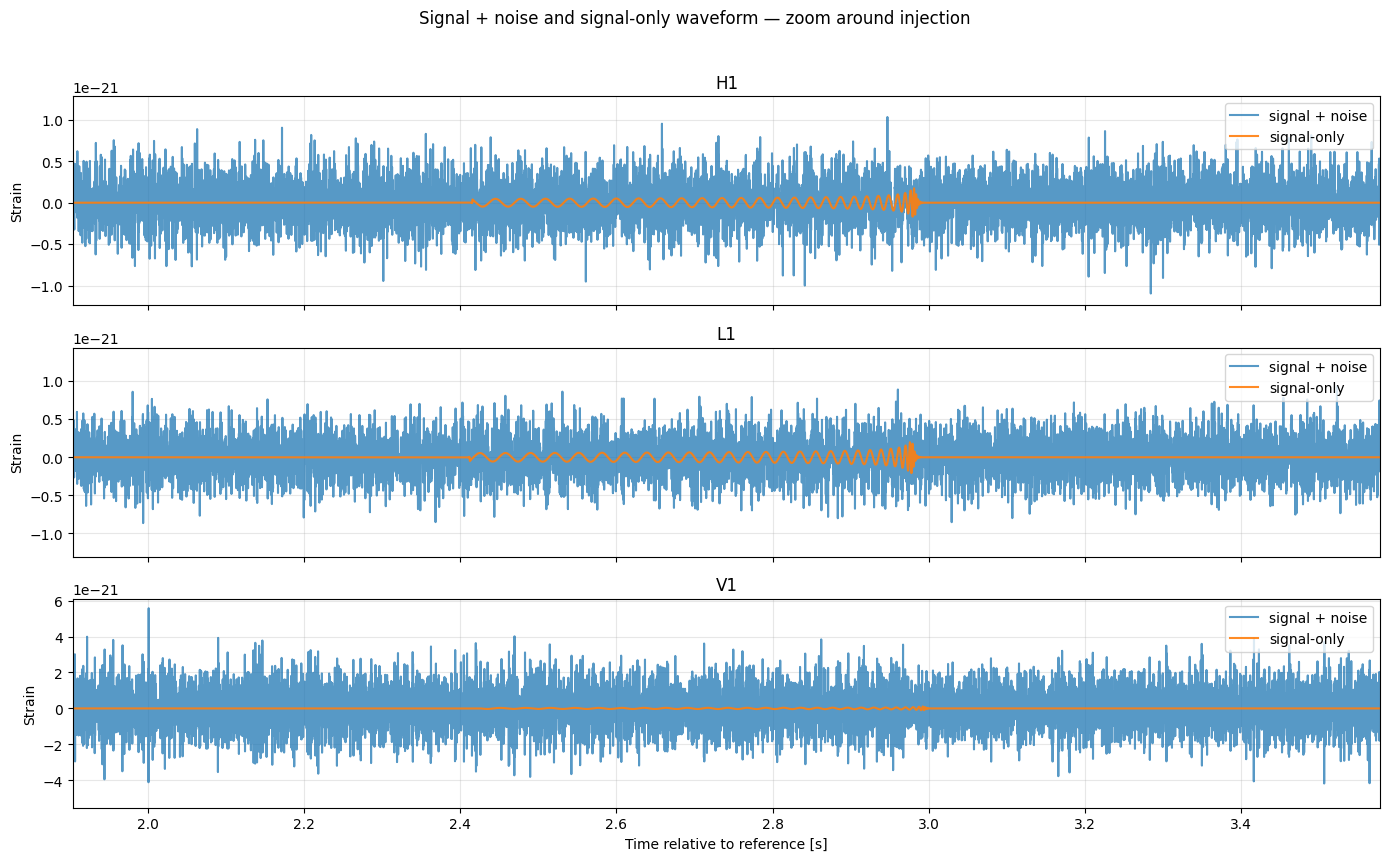

In [70]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise and signal-only waveform — zoom around injection",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    xlim=(zoom_start, zoom_end),
    signal_scale=1.0,
)

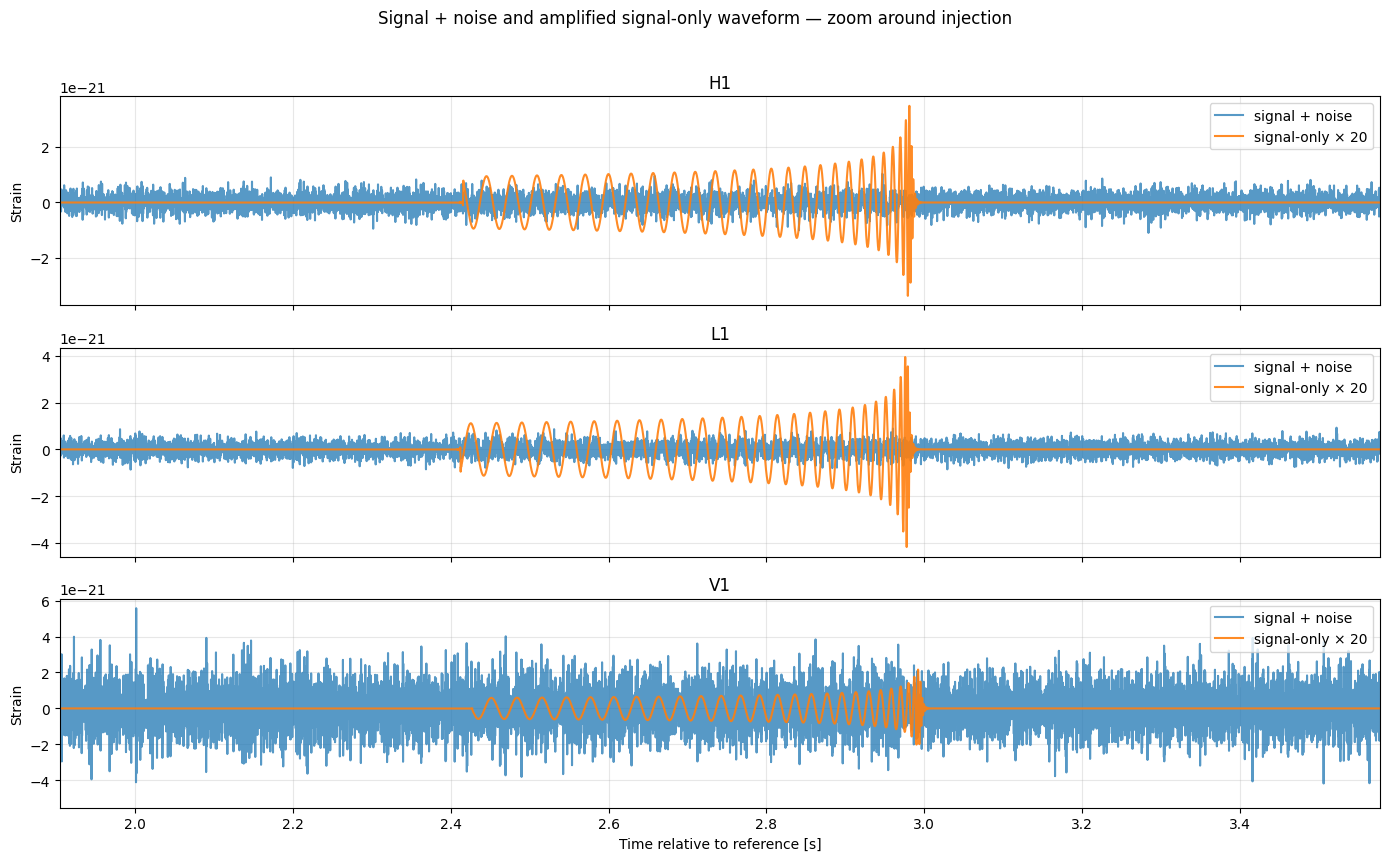

In [71]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise and amplified signal-only waveform — zoom around injection",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    xlim=(zoom_start, zoom_end),
    signal_scale=20.0,
)

### Detector Metadata

In [44]:
print("Injection metadata for each detector:")

for det, result in injected_results.items():
    print()
    print(det)
    print("  signal_start_time:", result.signal_start_time)
    print("  signal_end_time:", result.signal_end_time)
    print("  segment_start_time:", result.segment_start_time)
    print("  segment_end_time:", result.segment_end_time)
    print("  signal_start_index:", result.signal_start_index)
    print("  signal_end_index:", result.signal_end_index)
    print("  n_signal_samples:", result.n_signal_samples)
    print("  n_injected_samples:", result.n_injected_samples)
    print("  is_partially_clipped:", result.is_partially_clipped)

Injection metadata for each detector:

H1
  signal_start_time: 1126259461.4084473
  signal_end_time: 1126259462.0668945
  segment_start_time: 1126259459.0008156
  segment_end_time: 1126259491.0008156
  signal_start_index: 9862
  signal_end_index: 12559
  n_signal_samples: 2697
  n_injected_samples: 2697
  is_partially_clipped: False

L1
  signal_start_time: 1126259461.4052734
  signal_end_time: 1126259462.0637207
  segment_start_time: 1126259459.0008156
  segment_end_time: 1126259491.0008156
  signal_start_index: 9849
  signal_end_index: 12546
  n_signal_samples: 2697
  n_injected_samples: 2697
  is_partially_clipped: False

V1
  signal_start_time: 1126259461.420166
  signal_end_time: 1126259462.0783691
  segment_start_time: 1126259459.0008156
  segment_end_time: 1126259491.0008156
  signal_start_index: 9910
  signal_end_index: 12606
  n_signal_samples: 2696
  n_injected_samples: 2696
  is_partially_clipped: False


## 12. Process the strain

The final model input is not the raw injected strain.

The configured processing pipeline may include:

- whitening;
- high-pass filtering;
- low-pass filtering;
- optional standardization;
- cropping back to the final fixed-duration output segment.

In the full pipeline, extra processing context is added before and after the final segment so that whitening/filter edge effects are removed outside the returned model input.

### 12.1 Raw processing example

For visualization, we first apply an identity-like processor. This keeps the segment length unchanged and makes it easier to compare raw signal/noise behavior.

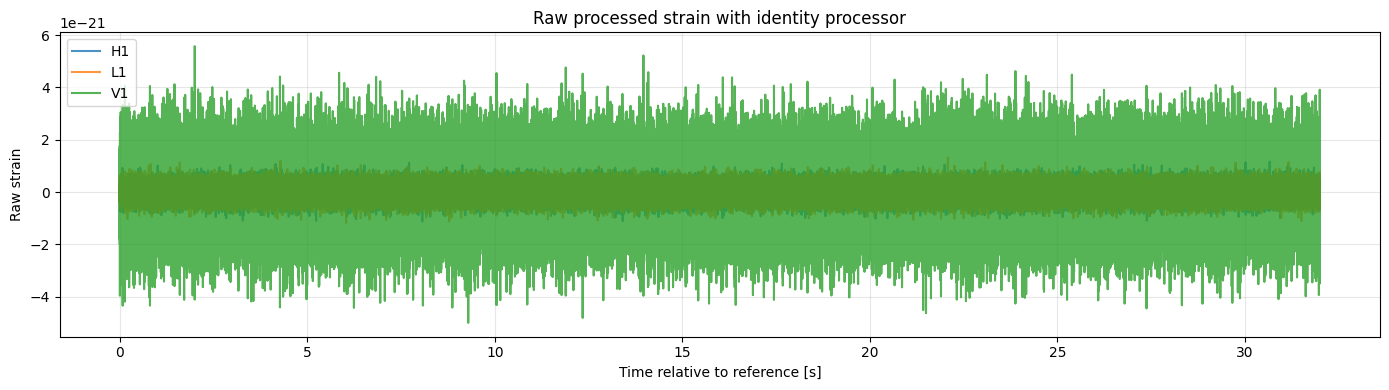

In [45]:
raw_processor = SignalProcessor(
    config=config,
    whitening_method="none",
    apply_highpass=False,
    apply_lowpass=False,
    apply_standardization=False,
    output_mode="restore_length",
)

raw_processed = raw_processor.process_network(
    strains=injected_strains,
    psds=None,
)

plot_timeseries_dict(
    raw_processed,
    title="Raw processed strain with identity processor",
    ylabel="Raw strain",
    relative_to=final_placement.segment_start_time,
)

### 12.2 Full processing through `DatasetBuilder`

The production processing configuration uses a longer processing-context segment and then crops back to the final output window.

Rather than manually rebuilding all context logic here, the recommended way to inspect the complete workflow is to use `DatasetBuilder`.

In [46]:
signal_processor_kwargs = {
    "whitening_method": "psd",
    "apply_highpass": True,
    "apply_lowpass": True,
    "apply_standardization": False,
    "output_mode": "crop_to_config",

    "whitening_low_frequency_cutoff": 30.0,
    "whitening_max_filter_duration": 0.5,
    "whitening_trunc_method": "hann",

    "highpass_frequency": 30.0,
    "lowpass_frequency": 512.0,

    "fir_order": 256,
    "fir_beta": 5.0,
    "remove_corrupted": True,
}

parameter_sampler_kwargs = {
    "regime": "BBH",
    "fixed": {
        "mass_1": 20.0,
        "mass_2": 20.0,
        "spin_1z": 0.0,
        "spin_2z": 0.0,
    },
}

In [47]:
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=detector_names,
    signal_processor_kwargs=signal_processor_kwargs,
    label_transformer_kwargs={},
    parameter_sampler_kwargs=parameter_sampler_kwargs,
    rng=np.random.default_rng(1234),
)

## 13. Build one complete dataset sample

We now use the full builder to generate one complete sample.

This performs the complete workflow:

1. sample or receive physical parameters;
2. generate waveform;
3. project to detectors;
4. select the network window;
5. compute signal-only SNR;
6. rescale distance if needed;
7. generate detector noise with processing context;
8. inject the signal;
9. process the strain;
10. crop to the final fixed-duration segment;
11. build the regression label vector.

In [48]:
sample = builder.build_sample(
    standardize_labels=False,
    geocentric_coalescence_time=geocentric_coalescence_time,
    placement_policy="random_contained",
)

sample

DatasetSample(X=array([[ 10.96614217,  -2.32277435, -15.98791367, ...,   4.75766957,
          9.07618763,  13.87112232],
       [  3.23321914,  -4.27767771, -15.34898612, ...,   0.23133324,
          0.35969118,   1.1036105 ],
       [-10.93590095, -15.69153669, -18.29918993, ..., -18.15887258,
         -9.40804556,  -6.56927892]], shape=(3, 131072)), y=array([17.41101127, 40.        ,  0.        ]), parameters=CBCParameters(mass_1=20.0, mass_2=20.0, distance=677.6241162495483, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156), metadata={'simulation': {'sampling_frequency': 4096.0, 'duration': 32.0, 'delta_t': 0.000244140625, 'length': 131072, 'delta_f': 0.03125, 'flength': 65537, 'low_frequency_cutoff': 30.0, 'waveform_approximant': 'SEOBNRv4_opt', 'target_network_snr_range': (10.0, 25.0), 'snr_relative_tolerance': 0.05, 'truncation_policy': 'keep_last_segment', 'required

In [49]:
print("X shape:", sample.X.shape)
print("y shape:", sample.y.shape)
print("y:", sample.y)
print()
print("parameters:", sample.parameters)
print()
print("metadata keys:")
print(sample.metadata.keys())

X shape: (3, 131072)
y shape: (3,)
y: [17.41101127 40.          0.        ]

parameters: CBCParameters(mass_1=20.0, mass_2=20.0, distance=677.6241162495483, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156)

metadata keys:
dict_keys(['simulation', 'initial_parameters', 'final_parameters', 'geocentric_coalescence_time', 'detectors', 'placement_policy', 'waveform', 'windowing', 'projection', 'placement', 'snr', 'injection', 'noise', 'processing', 'processing_context', 'labels'])


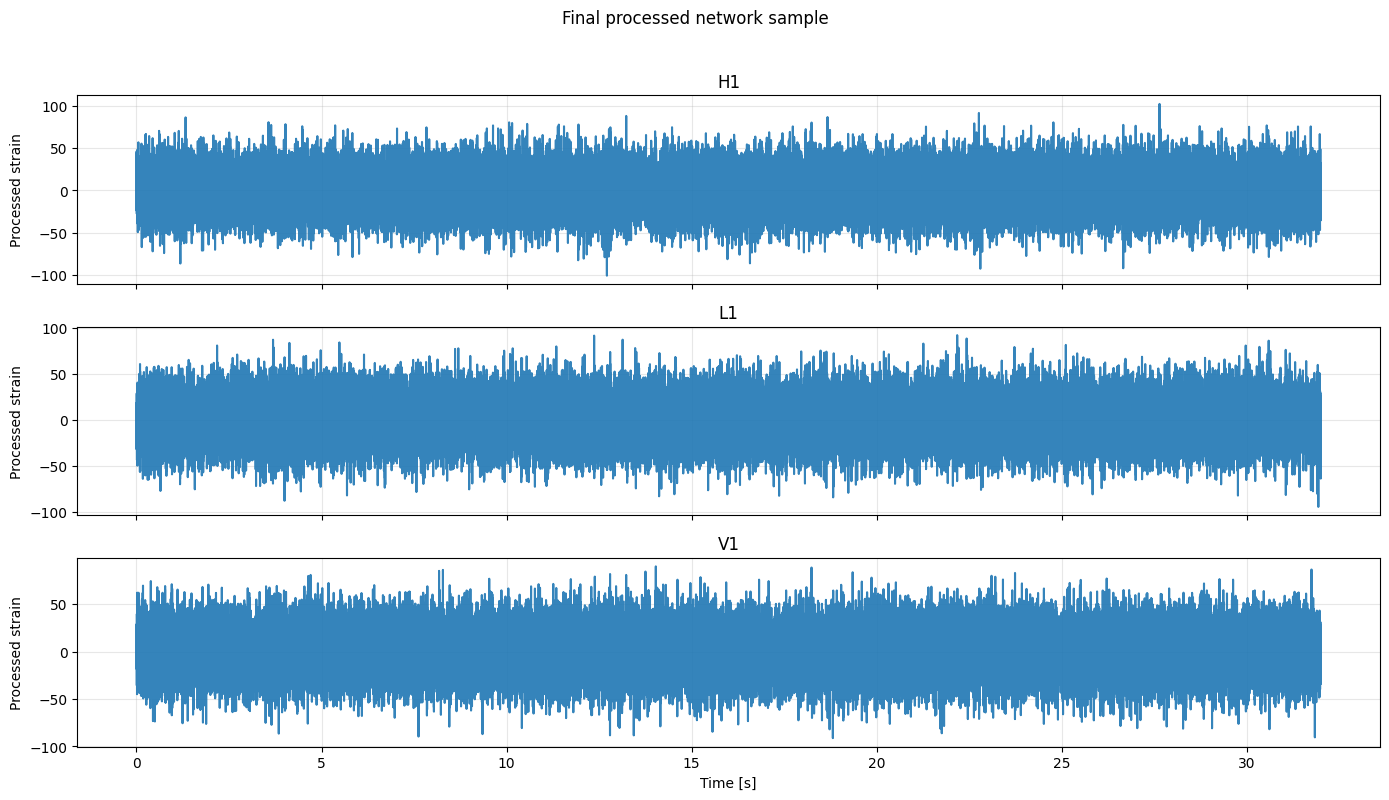

In [72]:
plot_array_network_subplots(
    sample.X,
    detector_names=detector_names,
    sampling_frequency=config.sampling_frequency,
    title="Final processed network sample",
)

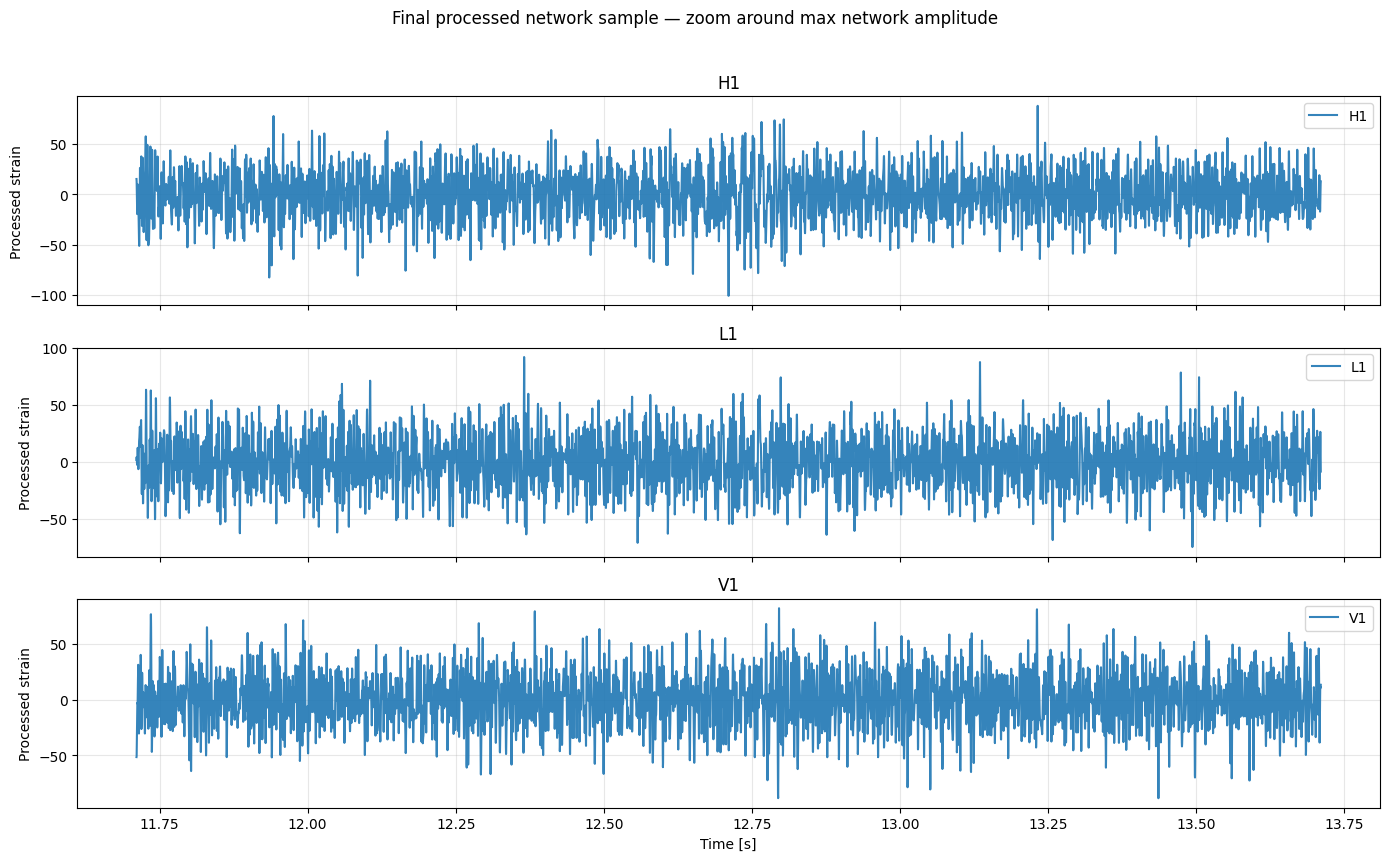

In [73]:
network_abs = np.sqrt(np.sum(sample.X ** 2, axis=0))
peak_idx = int(np.argmax(network_abs))

window_seconds = 2.0
half_window = int(0.5 * window_seconds * config.sampling_frequency)

i0 = max(0, peak_idx - half_window)
i1 = min(sample.X.shape[-1], peak_idx + half_window)

t = np.arange(sample.X.shape[-1]) / config.sampling_frequency

fig, axes = plt.subplots(
    len(detector_names),
    1,
    figsize=(14, 2.8 * len(detector_names)),
    sharex=True,
)

if len(detector_names) == 1:
    axes = [axes]

for det_idx, det in enumerate(detector_names):
    axes[det_idx].plot(
        t[i0:i1],
        sample.X[det_idx, i0:i1],
        label=det,
        alpha=0.9,
    )
    axes[det_idx].set_ylabel("Processed strain")
    axes[det_idx].set_title(det)
    axes[det_idx].grid(alpha=0.3)
    axes[det_idx].legend(loc="upper right")

axes[-1].set_xlabel("Time [s]")

fig.suptitle("Final processed network sample — zoom around max network amplitude", y=1.02)
plt.tight_layout()
plt.show()

## 14. Inspect sample metadata

The sample metadata is useful for debugging, validation, and dataset auditing.

It includes information about:

- simulation configuration;
- initial and final parameters;
- waveform generation;
- detector projection;
- selected window;
- segment placement;
- SNR before and after distance rescaling;
- injection indices and clipping;
- noise and processing configuration;
- label transformation.

In [52]:
print_dict_tree(sample.metadata, max_depth=3)

simulation
  sampling_frequency
    float: 4096.0
  duration
    float: 32.0
  delta_t
    float: 0.000244140625
  length
    int: 131072
  delta_f
    float: 0.03125
  flength
    int: 65537
  low_frequency_cutoff
    float: 30.0
  waveform_approximant
    str: SEOBNRv4_opt
  target_network_snr_range
    tuple: (10.0, 25.0)
  snr_relative_tolerance
    float: 0.05
  truncation_policy
    str: keep_last_segment
  required_final_duration
    float: 1.0
  processing_context_start_samples
    int: 1664
  processing_context_end_samples
    int: 1664
  processing_context_start_seconds
    float: 0.40625
  processing_context_end_seconds
    float: 0.40625
  processing_length
    int: 134400
  processing_duration
    float: 32.8125
  processing_delta_f
    float: 0.030476190476190476
  processing_flength
    int: 67201
  simulation_regime
    str: BBH
  waveform_family
    str: IMR
  event_time_reference
    str: geocentric
  snr_on_truncated_signal
    bool: True
initial_parameters
  mass_1


In [53]:
print("Simulation metadata:")
pprint(sample.metadata["simulation"])

Simulation metadata:
{'delta_f': 0.03125,
 'delta_t': 0.000244140625,
 'duration': 32.0,
 'event_time_reference': 'geocentric',
 'flength': 65537,
 'length': 131072,
 'low_frequency_cutoff': 30.0,
 'processing_context_end_samples': 1664,
 'processing_context_end_seconds': 0.40625,
 'processing_context_start_samples': 1664,
 'processing_context_start_seconds': 0.40625,
 'processing_delta_f': 0.030476190476190476,
 'processing_duration': 32.8125,
 'processing_flength': 67201,
 'processing_length': 134400,
 'required_final_duration': 1.0,
 'sampling_frequency': 4096.0,
 'simulation_regime': 'BBH',
 'snr_on_truncated_signal': True,
 'snr_relative_tolerance': 0.05,
 'target_network_snr_range': (10.0, 25.0),
 'truncation_policy': 'keep_last_segment',
 'waveform_approximant': 'SEOBNRv4_opt',
 'waveform_family': 'IMR'}


In [54]:
print("Initial parameters:")
pprint(sample.metadata["initial_parameters"])

print()
print("Final parameters:")
pprint(sample.metadata["final_parameters"])

Initial parameters:
{'chi_eff': 0.0,
 'chirp_mass': 17.411011265922482,
 'dec': -0.8692072862628579,
 'distance': 4631.581922066986,
 'inclination': 2.06759669959222,
 'mass_1': 20.0,
 'mass_2': 20.0,
 'polarization_angle': 6.05748854826156,
 'ra': 2.004945948992312,
 'spin_1z': 0.0,
 'spin_2z': 0.0,
 'total_mass': 40.0}

Final parameters:
{'chi_eff': 0.0,
 'chirp_mass': 17.411011265922482,
 'dec': -0.8692072862628579,
 'distance': 677.6241162495483,
 'inclination': 2.06759669959222,
 'mass_1': 20.0,
 'mass_2': 20.0,
 'polarization_angle': 6.05748854826156,
 'ra': 2.004945948992312,
 'spin_1z': 0.0,
 'spin_2z': 0.0,
 'total_mass': 40.0}


In [55]:
print("SNR metadata:")
pprint(sample.metadata["snr"])

SNR metadata:
{'distance_after_rescale': 677.6241162495483,
 'distance_before_rescale': 4631.581922066986,
 'final_detector_snrs': {'H1': 12.611473196132193,
                         'L1': 7.639107532405679,
                         'V1': 7.658724206915124},
 'final_network_snr': 16.61509183080267,
 'initial_detector_snrs': {'H1': 1.8451230104378895,
                           'L1': 1.1176404903729997,
                           'V1': 1.1205105101528254},
 'initial_network_snr': 2.4308728869958474,
 'snr_rescaled': True,
 'snr_rescaling_reason': 'outside_target_range',
 'target_network_snr': 16.615091830802672}


In [56]:
print("Placement metadata:")
pprint(sample.metadata["placement"])

Placement metadata:
{'earliest_signal_start_time': 1126259461.4294434,
 'enforce_safe_margins': True,
 'latest_signal_end_time': 1126259462.097168,
 'margin_after_signal': 19.10864019393921,
 'margin_before_signal': 12.223635196685791,
 'margins_respected': True,
 'placement_policy': 'random_contained',
 'safe_margin_end': 0.0,
 'safe_margin_start': 0.0,
 'segment_end_time': 1126259481.2058082,
 'segment_start_time': 1126259449.2058082,
 'signal_network_duration': 0.667724609375,
 'valid_start_max': 1126259461.4294434,
 'valid_start_min': 1126259430.097168}


In [57]:
print("Injection metadata:")
pprint(sample.metadata["injection"])

Injection metadata:
{'H1': {'is_partially_clipped': False,
        'n_clipped_after': 0,
        'n_clipped_before': 0,
        'n_injected_samples': 2697,
        'n_signal_samples': 2697,
        'overlap_end_index_signal': 2697,
        'overlap_end_index_strain': 54467,
        'overlap_start_index_signal': 0,
        'overlap_start_index_strain': 51770,
        'segment_end_time': 1126259481.6120582,
        'segment_start_time': 1126259448.7995582,
        'signal_end_index': 54467,
        'signal_end_time': 1126259462.097168,
        'signal_start_index': 51770,
        'signal_start_time': 1126259461.4387207},
 'L1': {'is_partially_clipped': False,
        'n_clipped_after': 0,
        'n_clipped_before': 0,
        'n_injected_samples': 2697,
        'n_signal_samples': 2697,
        'overlap_end_index_signal': 2697,
        'overlap_end_index_strain': 54429,
        'overlap_start_index_signal': 0,
        'overlap_start_index_strain': 51732,
        'segment_end_time': 1126

In [58]:
for det in detector_names:
    inj = sample.metadata["injection"][det]

    relative_start = inj["signal_start_time"] - inj["segment_start_time"]
    relative_end = inj["signal_end_time"] - inj["segment_start_time"]

    print(det)
    print("  relative signal start [s]:", relative_start)
    print("  relative signal end   [s]:", relative_end)
    print("  signal_start_index:", inj["signal_start_index"])
    print("  signal_end_index:", inj["signal_end_index"])

H1
  relative signal start [s]: 12.639162540435791
  relative signal end   [s]: 13.297609806060791
  signal_start_index: 51770
  signal_end_index: 54467
L1
  relative signal start [s]: 12.629885196685791
  relative signal end   [s]: 13.288332462310791
  signal_start_index: 51732
  signal_end_index: 54429
V1
  relative signal start [s]: 12.629885196685791
  relative signal end   [s]: 13.288088321685791
  signal_start_index: 51732
  signal_end_index: 54428


## 15. Regression labels

The regression target used by the CNN is:

$$
y = [\mathcal{M}_c, M_\mathrm{tot}, \chi_\mathrm{eff}]
$$

where:

- $\mathcal{M}_c$ is the chirp mass;
- $M_\mathrm{tot}$ is the total mass;
- $\chi_\mathrm{eff}$ is the effective aligned spin.

For this demo we use physical labels without standardization. In training, label standardization should use statistics computed from the training set only.

In [59]:
label_transformer = LabelTransformer()

physical_labels = label_transformer.transform(
    sample.parameters,
    standardize=False,
)

print("Label names:", label_transformer.label_names)
print("Physical labels:", physical_labels)

Label names: ('chirp_mass', 'total_mass', 'chi_eff')
Physical labels: [17.41101127 40.          0.        ]


In [60]:
print("From sample.y:")
print(sample.y)

assert np.allclose(sample.y, physical_labels)

From sample.y:
[17.41101127 40.          0.        ]


## 16. Build a tiny batch

Finally, we generate a tiny batch to verify that the same workflow works for more than one sample.

This is still a demo-scale operation. Full datasets should be generated with the script-based HDF5 pipeline.

In [61]:
batch = builder.build_dataset(
    num_samples=2,
    standardize_labels=False,
    geocentric_coalescence_time=geocentric_coalescence_time,
    placement_policy="random_contained",
    progress_every=1,
)

print("X shape:", batch.X.shape)
print("y shape:", batch.y.shape)
print("number of parameter objects:", len(batch.parameters))
print("number of metadata entries:", len(batch.metadata))

Built sample 1 of 2 --> 50.0% completed (attempts=1, failed=0, elapsed=9.3s, 9.26s/sample, 0.11 samples/s)
Built sample 2 of 2 --> 100.0% completed (attempts=2, failed=0, elapsed=15.9s, 7.96s/sample, 0.13 samples/s)
--> DATASET GENERATED with 2 valid samples after 2 attempts. Failed samples: 0 (0.0% failure rate). Total time: 15.9s (7.96s/sample, 0.13 samples/s).
X shape: (2, 3, 131072)
y shape: (2, 3)
number of parameter objects: 2
number of metadata entries: 2


In [62]:
m1 = np.array([p.mass_1 for p in batch.parameters])
m2 = np.array([p.mass_2 for p in batch.parameters])
total_mass = np.array([p.total_mass for p in batch.parameters])
chirp_mass = np.array([p.chirp_mass for p in batch.parameters])
chi_eff = np.array([p.chi_eff for p in batch.parameters])

print("mass_1:", m1)
print("mass_2:", m2)
print("total_mass:", total_mass)
print("chirp_mass:", chirp_mass)
print("chi_eff:", chi_eff)

assert batch.X.shape == (2, len(detector_names), config.length)
assert np.allclose(m1, 20.0)
assert np.allclose(m2, 20.0)
assert np.allclose(chi_eff, 0.0)

mass_1: [20. 20.]
mass_2: [20. 20.]
total_mass: [40. 40.]
chirp_mass: [17.41101127 17.41101127]
chi_eff: [0. 0.]


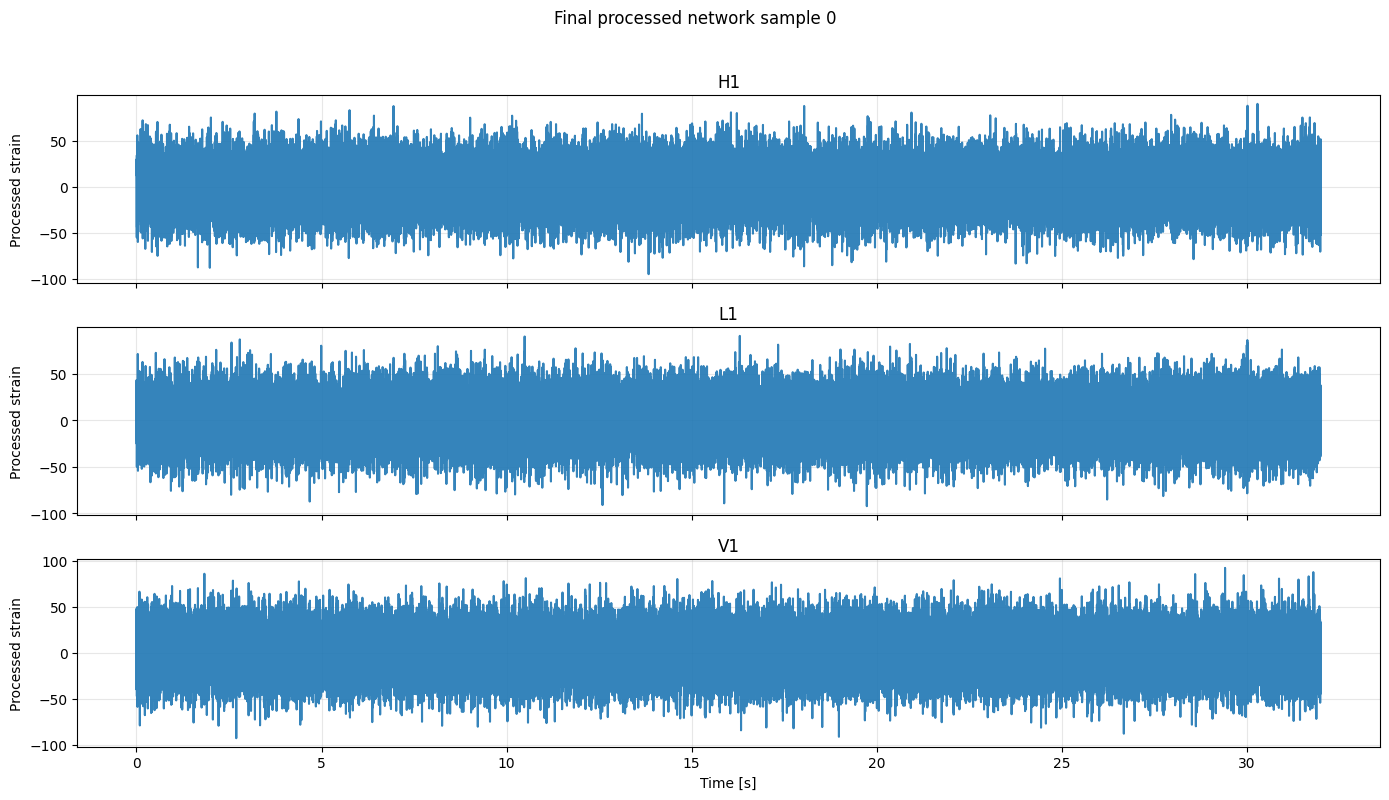

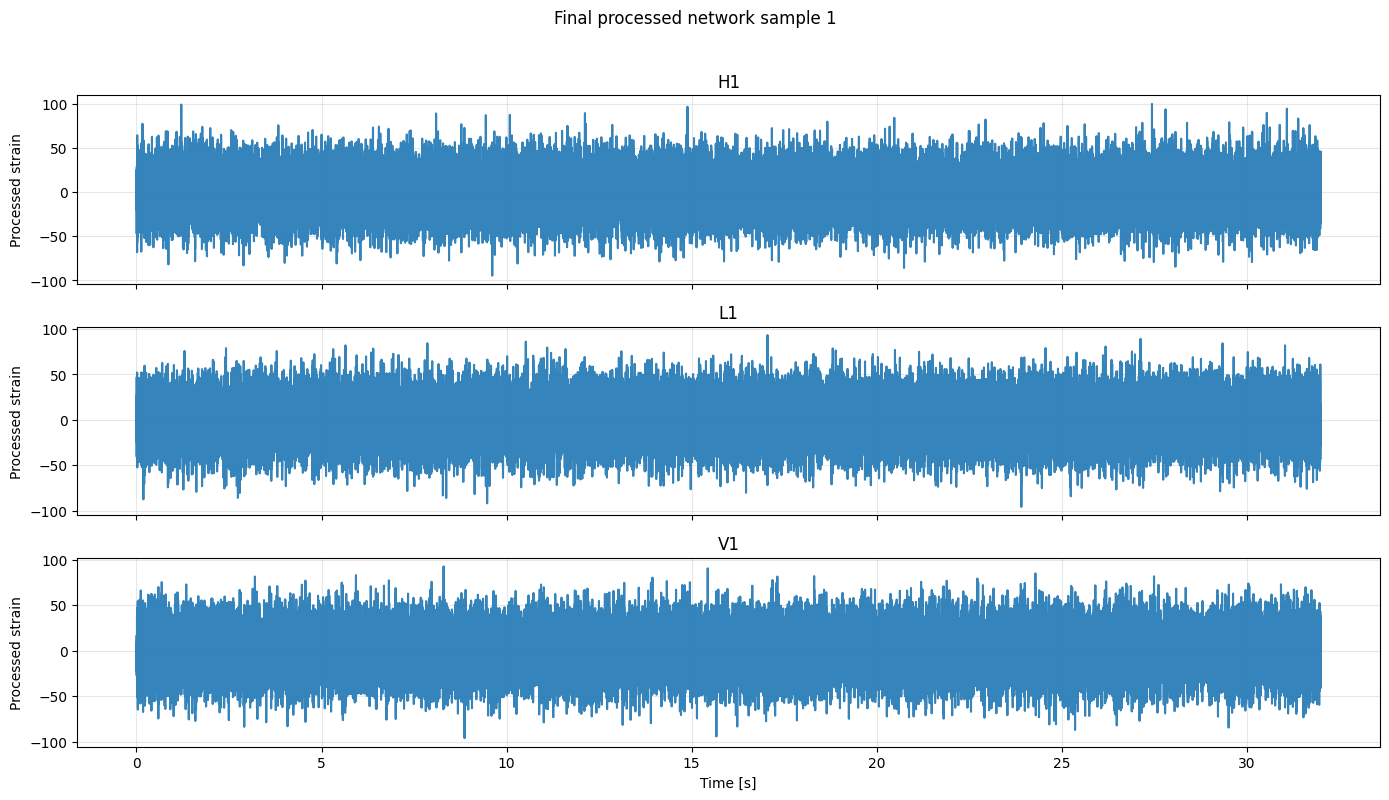

In [74]:
for sample_idx in range(batch.X.shape[0]):
    plot_array_network_subplots(
        batch.X[sample_idx],
        detector_names=detector_names,
        sampling_frequency=config.sampling_frequency,
        title=f"Final processed network sample {sample_idx}",
    )

## 17. Summary

This notebook walked through the signal-generation workflow step by step.

The main stages were:

1. configure the simulation;
2. define or sample CBC parameters;
3. generate geocentric plus/cross waveforms;
4. project the waveform onto the detector network;
5. select a common detector-network time window;
6. place the signal into a fixed-duration segment;
7. compute signal-only SNR;
8. rescale distance if needed;
9. inject the signal into detector noise;
10. process the noisy strain;
11. build final model-ready samples and labels.

For research-scale generation, use the script-based HDF5 pipeline with versioned JSON configuration files.